# Grafik Kategori A-D

Setiap kategori memakai data `Kelas C_Housing.csv` dan visualisasi dibuat dengan `matplotlib.pyplot`.

## Import Library dan Dataset

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Kelas C_Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Kategori A (Agregasi)

Menghitung rata-rata harga rumah (`price`) berdasarkan status furnishing (`furnishingstatus`). Output sudah sesuai dengan deskripsi karena memakai agregasi `groupby` dan divisualisasikan dalam bentuk Bar Chart.

In [36]:
price_by_furniture = df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)
price_by_furniture

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

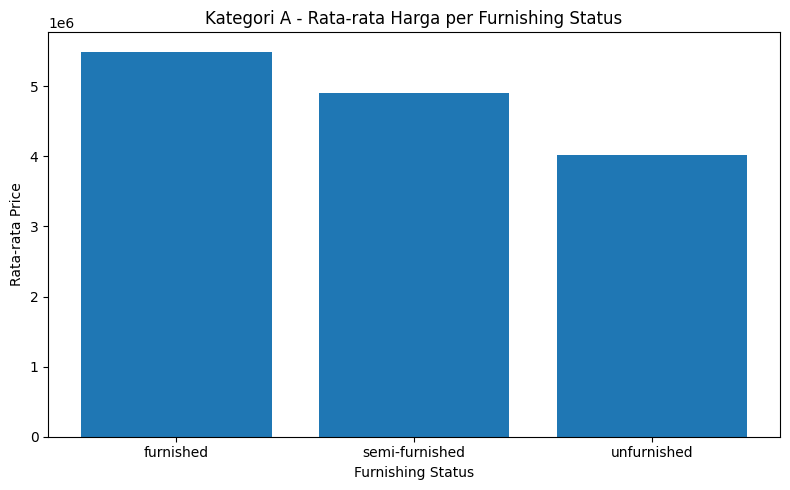

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(price_by_furniture.index, price_by_furniture.values)
plt.title("Kategori A - Rata-rata Harga per Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Rata-rata Price")
plt.tight_layout()
plt.show()

## Kategori B (Tren/Filter)

Memfilter rumah yang berada di jalan utama (`mainroad = "yes"`) dan memiliki AC (`airconditioning = "yes"`), lalu menghitung rata-rata `price`. Output sudah disesuaikan dengan deskripsi: filter `parking >= 2` dari notebook lama tidak dipakai karena tidak diminta pada instruksi ini.

In [38]:
breakdown = df.groupby(['mainroad', 'airconditioning'])['price'].mean().reset_index()
breakdown.columns = ['mainroad', 'airconditioning', 'rata_rata_price']
breakdown['jumlah_data'] = df.groupby(['mainroad', 'airconditioning']).size().values
breakdown

,mainroad,airconditioning,rata_rata_price,jumlah_data
0,no,no,3.237438e+06,62
1,no,yes,4.066300e+06,15
2,yes,no,4.382226e+06,311
3,yes,yes,6.199232e+06,157


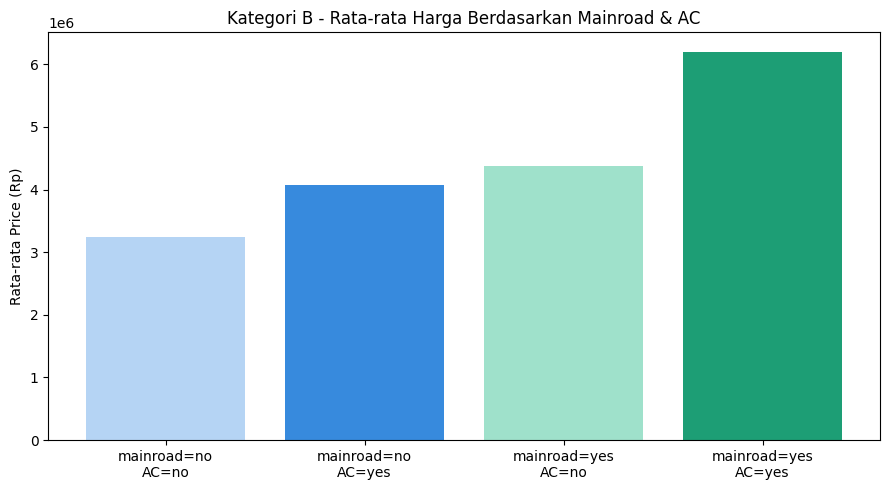

In [39]:
labels = [f"mainroad={r['mainroad']}\nAC={r['airconditioning']}" for _, r in breakdown.iterrows()]

plt.figure(figsize=(9, 5))
plt.bar(labels, breakdown['rata_rata_price'], color=colors)
plt.title("Kategori B - Rata-rata Harga Berdasarkan Mainroad & AC")
plt.ylabel("Rata-rata Price (Rp)")
plt.tight_layout()
plt.show()

## Kategori C (Korelasi)

Menganalisis hubungan antara luas tanah (`area`) dan harga jual rumah (`price`). Output sesuai dengan deskripsi karena menampilkan nilai korelasi dan Scatter Plot untuk melihat pola hubungan kedua variabel.

In [40]:
correlation = df["area"].corr(df["price"])
print(f"Korelasi area dan price: {correlation:.4f}")

Korelasi area dan price: 0.5360


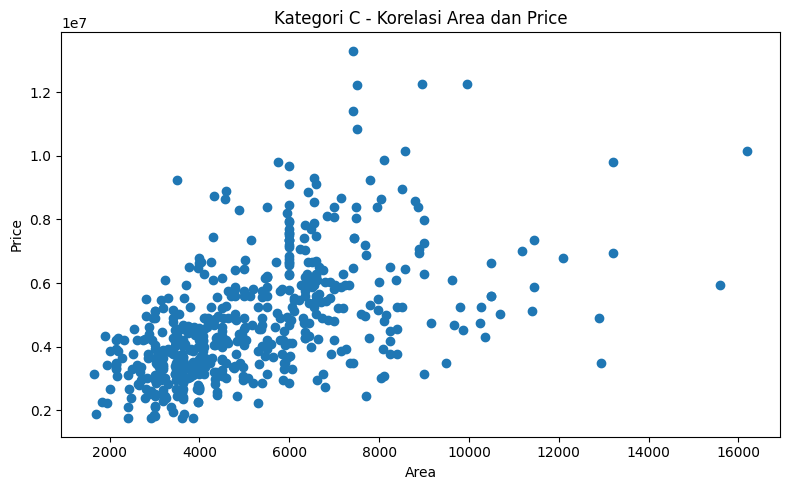

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(df["area"], df["price"])
plt.title("Kategori C - Korelasi Area dan Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## Kategori D (Distribusi)

Mengidentifikasi pencilan pada data harga rumah (`price`) menggunakan metode IQR, kemudian menampilkan distribusi dan outlier dengan Boxplot. Output sesuai dengan deskripsi karena boxplot memperlihatkan sebaran data dan titik pencilan.

In [42]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

pd.DataFrame({
    "Q1": [q1],
    "Q3": [q3],
    "IQR": [iqr],
    "batas_bawah": [lower_bound],
    "batas_atas": [upper_bound],
    "jumlah_outlier": [len(outliers)]
})

,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_outlier
0,3430000.0,5740000.0,2310000.0,-35000.0,9205000.0,15


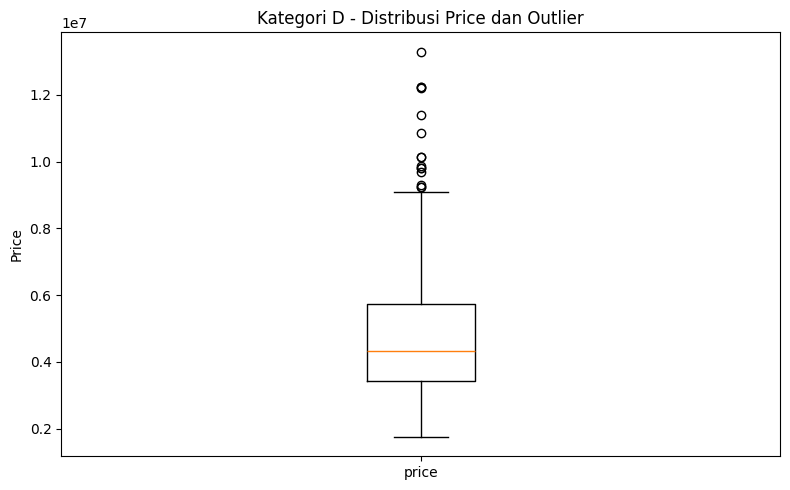

In [43]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["price"]) 
plt.title("Kategori D - Distribusi Price dan Outlier")
plt.ylabel("Price")
plt.xticks([1], ["price"])
plt.tight_layout()
plt.show()

# Grafik Gabungan

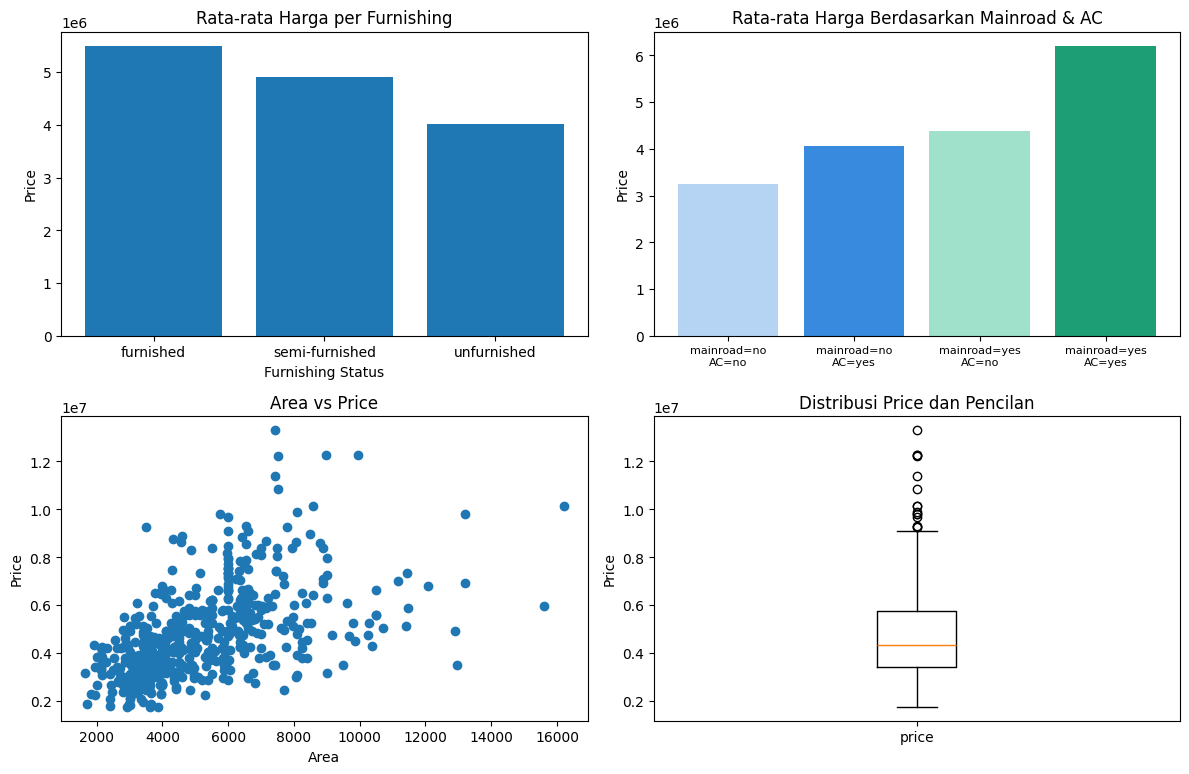

In [44]:
price_by_furniture = df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)

breakdown = df.groupby(['mainroad', 'airconditioning'])['price'].mean().reset_index()
labels = [f"mainroad={r['mainroad']}\nAC={r['airconditioning']}" for _, r in breakdown.iterrows()]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(price_by_furniture.index, price_by_furniture.values)
axes[0, 0].set_title("Rata-rata Harga per Furnishing")
axes[0, 0].set_xlabel("Furnishing Status")
axes[0, 0].set_ylabel("Price")

axes[0, 1].bar(labels, breakdown['price'], color=colors)
axes[0, 1].set_title("Rata-rata Harga Berdasarkan Mainroad & AC")
axes[0, 1].set_ylabel("Price")
axes[0, 1].tick_params(axis="x", labelsize=8)

axes[1, 0].scatter(df["area"], df["price"])
axes[1, 0].set_title("Area vs Price")
axes[1, 0].set_xlabel("Area")
axes[1, 0].set_ylabel("Price")

axes[1, 1].boxplot(df["price"])
axes[1, 1].set_title("Distribusi Price dan Pencilan")
axes[1, 1].set_ylabel("Price")
axes[1, 1].set_xticklabels(["price"])

plt.tight_layout()
plt.show()